[INFO] Centro=(599,1021), radio=547px
[INFO] Segundero ROJO detectado (4464px)

  Hora detectada: 6:39:21
  Horaria  → 179.5° → 6h
  Minutera → 236.0° → 39min
  Segundera→ 129.5° → 21seg


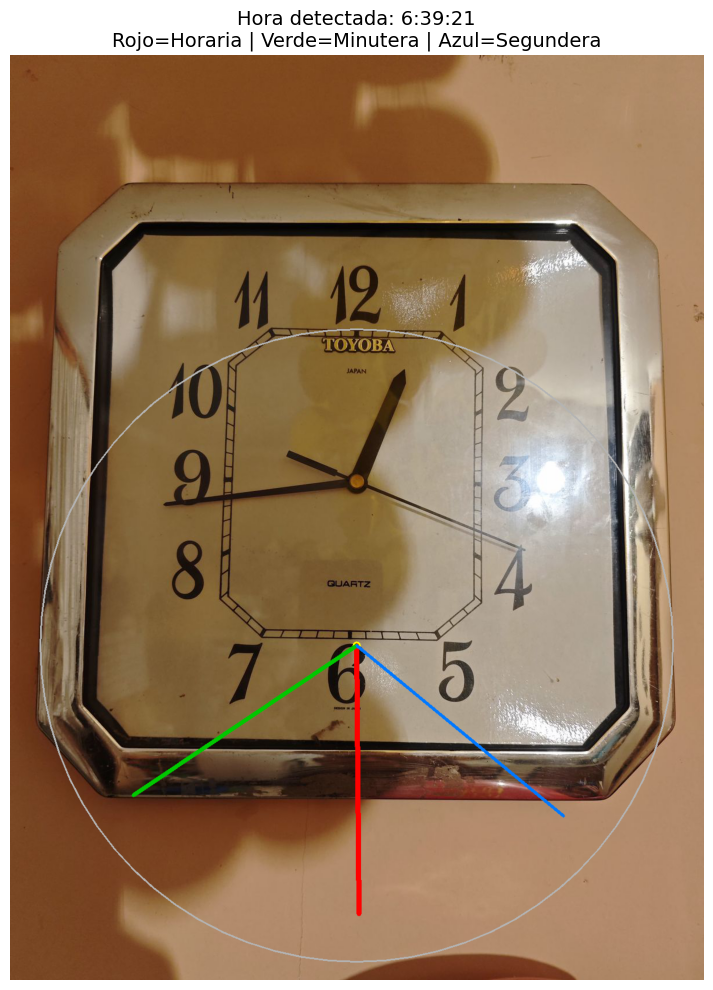

In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

nombre_imagen = "relojp5.jpeg"

# 1. Cargar la imagen
imagen_bgr = cv2.imread(nombre_imagen)
if imagen_bgr is None:
    print(f"Error: no se pudo abrir '{nombre_imagen}'")
else:
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    alto, ancho = imagen_bgr.shape[:2]
    gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

    # 2. Encontrar el círculo del reloj (centro y radio reales)
    # Ecualizo y difumino un poco para que se vean mejor los bordes
    ecualizada = cv2.equalizeHist(cv2.GaussianBlur(gris, (5, 5), 1))
    circulos = cv2.HoughCircles(ecualizada, cv2.HOUGH_GRADIENT, dp=1.2,
        minDist=min(alto, ancho) // 2, param1=100, param2=40,
        minRadius=int(min(alto, ancho) * 0.25),
        maxRadius=int(min(alto, ancho) * 0.55))

    if circulos is not None:
        cx, cy, r = np.round(circulos[0, 0]).astype(int)
    else:
        # Si no encuentra el círculo, usamos el centro de la imagen como aproximación
        cx, cy = ancho // 2, alto // 2
        r = int(min(alto, ancho) * 0.45)
    print(f"[INFO] Centro=({cx},{cy}), radio={r}px")

    # 3. Máscaras de color
    # Para el segundero: si hay bastantes píxeles rojos → segundero rojo; si no, asumimos negro
    R = imagen_rgb[:, :, 0].astype(int)
    G = imagen_rgb[:, :, 1].astype(int)
    B = imagen_rgb[:, :, 2].astype(int)

    mask_rojo  = ((R > 130) & (R - G > 50) & (R - B > 50)).astype(np.uint8) * 255
    mask_negro = ((R < 80)  & (G < 80)  & (B < 80)).astype(np.uint8) * 255

    # Recortamos las máscaras para que solo quede dentro del reloj
    mascara_reloj = np.zeros_like(gris)
    cv2.circle(mascara_reloj, (cx, cy), int(r * 0.88), 255, -1)
    cv2.circle(mascara_reloj, (cx, cy), int(r * 0.06),   0, -1)   # agujero central

    mask_rojo  = cv2.bitwise_and(mask_rojo,  mask_rojo,  mask=mascara_reloj)
    mask_negro = cv2.bitwise_and(mask_negro, mask_negro, mask=mascara_reloj)

    # Si hay muchos píxeles rojos, es un segundero rojo; si no, asumimos negro
    UMBRAL_ROJO = int(r * 0.5)
    pixeles_rojos = cv2.countNonZero(mask_rojo)

    if pixeles_rojos > UMBRAL_ROJO:
        segundero_rojo = True
        print(f"[INFO] Segundero ROJO detectado ({pixeles_rojos}px)")
    else:
        segundero_rojo = False
        print(f"[INFO] Sin rojo suficiente ({pixeles_rojos}px < {UMBRAL_ROJO}) → segundero negro")

    # 4. Perfil radial: para cada ángulo, cuántos píxeles hay en esa dirección
    N = 720   # cantidad de ángulos a probar (medio grado por paso)

    def perfil_radial(binaria, cx, cy, r, N=720):
        perfil = np.zeros(N)
        for i in range(N):
            ang = np.radians(i * 360 / N)
            for frac in np.linspace(0.06, 0.88, 100):
                px = int(cx + frac * r * np.sin(ang))
                py = int(cy - frac * r * np.cos(ang))
                if 0 <= px < binaria.shape[1] and 0 <= py < binaria.shape[0]:
                    if binaria[py, px] > 0:
                        perfil[i] += 1
        return perfil

    def suavizar(perfil, sigma=3):
        # Un filtro gaussiano simple para que el perfil quede más lindo
        tam    = sigma * 6 + 1
        x      = np.arange(tam) - tam // 2
        kernel = np.exp(-x**2 / (2 * sigma**2))
        kernel /= kernel.sum()
        return np.convolve(perfil, kernel, mode='same')

    def extraer_picos(perfil, N, n_picos=3):
        # Encuentra los picos más importantes del perfil
        p = suavizar(perfil.copy())
        if p.max() == 0:
            return []
        p = p / p.max()
        picos = []
        for _ in range(n_picos + 4):
            idx = int(np.argmax(p))
            if p[idx] < 0.25:
                break
            picos.append((idx * 360 / N, float(p[idx])))
            # Borramos la zona alrededor del pico para no repetir
            p[max(0, idx - 30):min(N, idx + 30)] = 0
        return picos

    # 5. Medir el grosor de una manecilla en una dirección dada
    def grosor_manecilla(ang_deg, cx, cy, r, binaria, n_pts=40):
        ang_rad  = np.radians(ang_deg)
        perp_rad = ang_rad + np.pi / 2
        grosores = []
        for frac in np.linspace(0.3, 0.8, n_pts):
            px0 = cx + frac * r * np.sin(ang_rad)
            py0 = cy - frac * r * np.cos(ang_rad)
            count = 0
            # Barremos perpendicularmente a la manecilla
            for d in np.linspace(-15, 15, 31):
                px = int(px0 + d * np.sin(perp_rad))
                py = int(py0 - d * np.cos(perp_rad))
                if 0 <= px < binaria.shape[1] and 0 <= py < binaria.shape[0]:
                    if binaria[py, px] > 0:
                        count += 1
            grosores.append(count)
        return float(np.median(grosores))

    # 6. Detectar cada manecilla según corresponda
    ang_seg = None   # ángulo del segundero (si existe)

    if segundero_rojo:
        # --- Segundero rojo: lo sacamos del perfil de la máscara roja
        p_seg   = perfil_radial(mask_rojo, cx, cy, r, N)
        picos_s = extraer_picos(p_seg, N, n_picos=2)

        if picos_s:
            ang_candidato = picos_s[0][0]
            ang_opuesto   = (ang_candidato + 180) % 360

            # Miramos hasta qué distancia llega la línea en cada dirección
            def distancia_maxima(ang_deg, binaria, cx, cy, r, n=150):
                ang_rad = np.radians(ang_deg)
                ultimo = 0.0
                for frac in np.linspace(0.05, 0.95, n):
                    px = int(cx + frac * r * np.sin(ang_rad))
                    py = int(cy - frac * r * np.cos(ang_rad))
                    if 0 <= px < binaria.shape[1] and 0 <= py < binaria.shape[0]:
                        if binaria[py, px] > 0:
                            ultimo = frac
                return ultimo

            dist_directo = distancia_maxima(ang_candidato, mask_rojo, cx, cy, r)
            dist_opuesto = distancia_maxima(ang_opuesto,   mask_rojo, cx, cy, r)

            # El extremo que más lejos llega es la punta del segundero
            ang_seg = ang_opuesto if dist_opuesto > dist_directo else ang_candidato
        else:
            ang_seg = 0.0

        # --- Horaria y minutera: son negras, buscamos los dos picos principales
        p_negro = perfil_radial(mask_negro, cx, cy, r, N)
        picos_n = extraer_picos(p_negro, N, n_picos=3)

        if len(picos_n) >= 2:
            ang_A, _ = picos_n[0]
            ang_B, _ = picos_n[1]
            gA = grosor_manecilla(ang_A, cx, cy, r, mask_negro)
            gB = grosor_manecilla(ang_B, cx, cy, r, mask_negro)
            # La más gruesa es la minutera, la otra la horaria
            if gA >= gB:
                ang_min, ang_hor = ang_A, ang_B
            else:
                ang_min, ang_hor = ang_B, ang_A
        else:
            print("[ERROR] No se detectaron suficientes manecillas negras.")
            exit()

    else:
        # --- Segundero negro: las tres manecillas son negras
        # Detectamos los primeros 3 picos y ordenamos por grosor
        # (minutera = más gruesa, horaria = intermedia, segundero = más delgada)
        p_negro = perfil_radial(mask_negro, cx, cy, r, N)
        picos_n = extraer_picos(p_negro, N, n_picos=4)

        if len(picos_n) < 2:
            print("[ERROR] No se detectaron suficientes manecillas.")
        elif len(picos_n) == 2:
            # Solo hay dos manecillas (sin segundero visible)
            ang_A, _ = picos_n[0]
            ang_B, _ = picos_n[1]
            gA = grosor_manecilla(ang_A, cx, cy, r, mask_negro)
            gB = grosor_manecilla(ang_B, cx, cy, r, mask_negro)
            if gA >= gB:
                ang_min, ang_hor = ang_A, ang_B
            else:
                ang_min, ang_hor = ang_B, ang_A
        else:
            # Caso con tres manecillas: ordenamos por grosor
            candidatas = []
            for ang, _ in picos_n[:3]:
                g = grosor_manecilla(ang, cx, cy, r, mask_negro)
                candidatas.append((ang, g))
            candidatas.sort(key=lambda x: x[1], reverse=True)  # de más gruesa a más delgada
            ang_min = candidatas[0][0]
            ang_hor = candidatas[1][0]
            ang_seg = candidatas[2][0]

    # 7. Calcular la hora, minutos y segundos
    hora    = round(ang_hor / 30) % 12 or 12
    minutos = int(ang_min  / 6)   % 60

    if ang_seg is not None:
        segundos = int(ang_seg / 6) % 60
        texto = f'{hora}:{minutos:02d}:{segundos:02d}'
    else:
        texto = f'{hora}:{minutos:02d}'

    print(f"\n{'='*40}")
    print(f"  Hora detectada: {texto}")
    print(f"{'='*40}")
    print(f"  Horaria  → {ang_hor:.1f}° → {hora}h")
    print(f"  Minutera → {ang_min:.1f}° → {minutos}min")
    if ang_seg is not None:
        print(f"  Segundera→ {ang_seg:.1f}° → {int(ang_seg/6)%60}seg")

    # 8. Dibujar el resultado sobre la imagen
    def dibujar_rayo(img, cx, cy, r, ang_deg, color, grosor_px):
        ang_rad = np.radians(ang_deg)
        x2 = int(cx + r * 0.85 * np.sin(ang_rad))
        y2 = int(cy - r * 0.85 * np.cos(ang_rad))
        cv2.line(img, (cx, cy), (x2, y2), color, grosor_px)

    resultado = imagen_rgb.copy()
    cv2.circle(resultado, (cx, cy), r, (180, 180, 180), 2)
    cv2.circle(resultado, (cx, cy), 7, (255, 255, 0), -1)   # centro amarillo

    dibujar_rayo(resultado, cx, cy, r, ang_hor, (255,   0,   0), 8)  # horaria en rojo
    dibujar_rayo(resultado, cx, cy, r, ang_min, (0,   200,   0), 5)  # minutera en verde
    if ang_seg is not None:
        dibujar_rayo(resultado, cx, cy, r, ang_seg, (0, 120, 255), 3)  # segundero en azul

    plt.figure(figsize=(10, 10))
    plt.imshow(resultado)
    plt.title(f'Hora detectada: {texto}\nRojo=Horaria | Verde=Minutera | Azul=Segundera',
              fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('resultado_reloj.png', dpi=150, bbox_inches='tight')
    plt.show()